# BÁO CÁO LAB 4.7: DỰ BÁO CHUỖI THỜI GIAN VỚI DỮ LIỆU KHÍ HẬU THỰC

## Thông tin sinh viên

- Họ và tên: Nguyễn Văn Anh Duy
- Mã sinh viên: SE181823
- Lớp: AI1803
- Môn học: DAT301m

---

## 1. Bối cảnh bài toán

Bài làm triển khai bài toán dự báo chuỗi thời gian từ dữ liệu nhiệt độ trung bình đất liền toàn cầu. Khác với bài lab gốc dùng dữ liệu giả lập, notebook này sử dụng dữ liệu thực từ tập `GlobalTemperatures.csv` nhằm tăng giá trị phân tích và khả năng nhận xét kết quả.

## 2. Mục tiêu thực hiện

- Xây dựng quy trình xử lý dữ liệu chuỗi thời gian theo dạng cửa sổ (`windowed dataset`).
- Huấn luyện mô hình hồi quy đơn giản theo đúng tinh thần của bài lab.
- So sánh mô hình baseline với một mô hình cải tiến nhằm giảm loss.
- Trực quan hóa dữ liệu, quá trình học và kết quả dự đoán bằng nhiều biểu đồ.
- Đánh giá chất lượng mô hình bằng các chỉ số `MSE` và `MAE`.

## 3. Dữ liệu sử dụng

- Nguồn dữ liệu: `GlobalTemperatures.csv`.
- Biến mục tiêu: `LandAverageTemperature`.
- Tần suất quan sát: theo tháng.
- Giai đoạn dữ liệu sau khi làm sạch: từ `1750-01` đến `2015-12`.

## 4. Quy trình thực hiện

1. Đọc và làm sạch dữ liệu nhiệt độ trung bình đất liền.
2. Trực quan hóa chuỗi thời gian và một số đặc trưng mô tả quan trọng.
3. Chia dữ liệu thành tập huấn luyện và tập xác thực.
4. Tạo `windowed dataset` để mô hình học theo ngữ cảnh thời gian gần nhất.
5. Huấn luyện mô hình baseline và mô hình cải tiến.
6. Dự đoán trên tập validation, đo sai số và phân tích residual.
7. Rút ra insight từ dữ liệu và đưa ra nhận xét tổng kết.

## 5. Định hướng mô hình

Mô hình baseline sử dụng một lớp `Dense(1)` nhằm bám sát yêu cầu cốt lõi của bài lab. Bên cạnh đó, một mô hình cải tiến được bổ sung để kiểm tra khả năng giảm loss thông qua chuẩn hóa dữ liệu, optimizer phù hợp hơn và cơ chế dừng sớm.

Tổng số quan sát hợp lệ: 3180
Khoảng thời gian dữ liệu: 1750-01-01 -> 2015-12-01


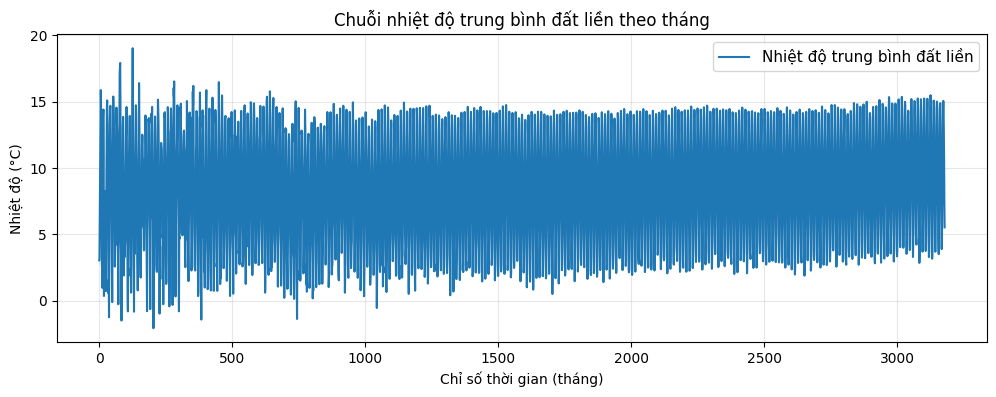

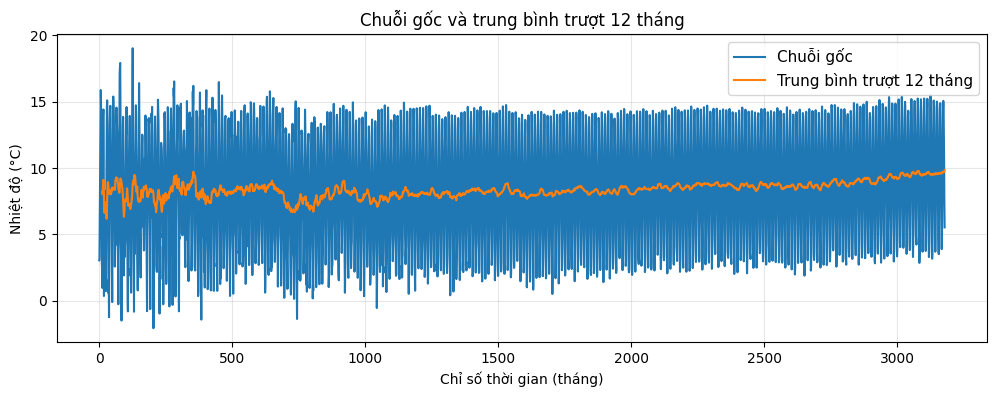

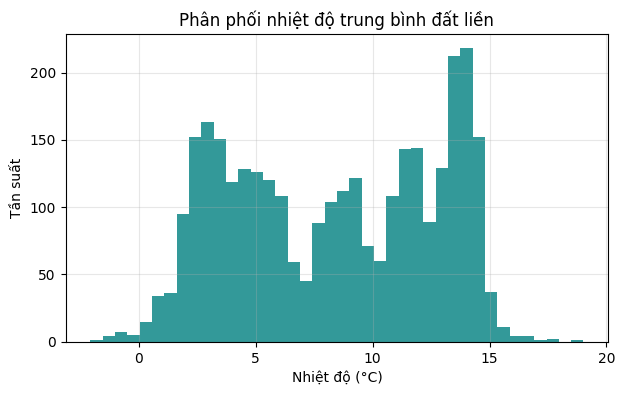

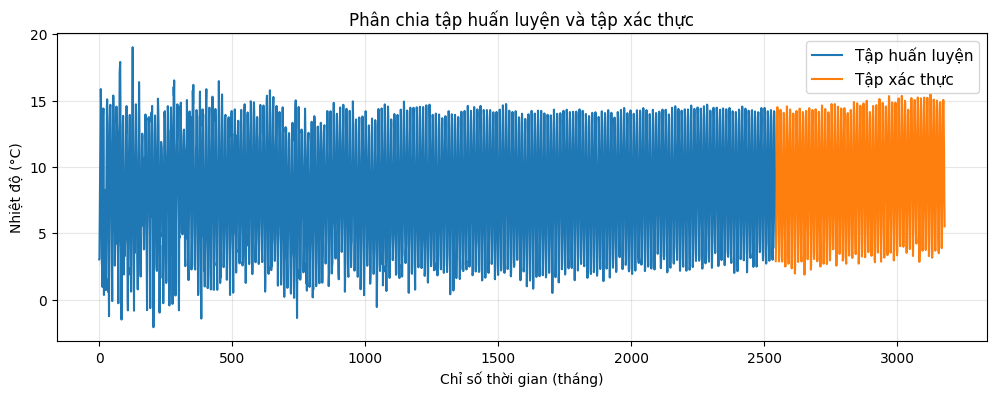

Kích thước batch cửa sổ: (32, 24)
Kích thước batch nhãn: (32,)
Số bước huấn luyện mỗi epoch: 78


In [11]:
# =========================
# Phần 1: Import thư viện và khai báo hàm hỗ trợ
# =========================
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# Thiết lập để kết quả có thể lặp lại
tf.random.set_seed(42)
np.random.seed(42)

def plot_series(time, series, format='-', start=0, end=None, label=None):
    plt.plot(time[start:end], series[start:end], format, label=label)
    plt.xlabel('Chỉ số thời gian (tháng)')
    plt.ylabel('Nhiệt độ (°C)')
    if label:
        plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    ds = ds.shuffle(shuffle_buffer)
    ds = ds.map(lambda w: (w[:-1], w[-1]))
    return ds.batch(batch_size).repeat().prefetch(tf.data.AUTOTUNE)

# =========================
# Phần 2: Đọc và làm sạch dữ liệu thực
# =========================
df = pd.read_csv('GlobalTemperatures.csv')
df.columns = [c.strip() for c in df.columns]
df['dt'] = pd.to_datetime(df['dt'])

# Chọn nhiệt độ trung bình đất liền theo tháng và loại bỏ giá trị khuyết thiếu
df_temp = df[['dt', 'LandAverageTemperature']].dropna().copy()
df_temp = df_temp.sort_values('dt').reset_index(drop=True)

time = np.arange(len(df_temp), dtype='float32')
series = df_temp['LandAverageTemperature'].astype('float32').to_numpy()

print('Tổng số quan sát hợp lệ:', len(series))
print('Khoảng thời gian dữ liệu:', df_temp['dt'].iloc[0].date(), '->', df_temp['dt'].iloc[-1].date())

# =========================
# Phần 3: Khám phá và trực quan hóa dữ liệu
# =========================
plt.figure(figsize=(12, 4))
plot_series(time, series, label='Nhiệt độ trung bình đất liền')
plt.title('Chuỗi nhiệt độ trung bình đất liền theo tháng')
plt.show()

rolling_12 = pd.Series(series).rolling(window=12).mean()
plt.figure(figsize=(12, 4))
plot_series(time, series, label='Chuỗi gốc', format='-')
plot_series(time, rolling_12.to_numpy(), label='Trung bình trượt 12 tháng', format='-')
plt.title('Chuỗi gốc và trung bình trượt 12 tháng')
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(series, bins=40, alpha=0.8, color='teal')
plt.title('Phân phối nhiệt độ trung bình đất liền')
plt.xlabel('Nhiệt độ (°C)')
plt.ylabel('Tần suất')
plt.grid(alpha=0.3)
plt.show()

# =========================
# Phần 4: Chia tập huấn luyện và tập xác thực
# =========================
split_time = int(len(series) * 0.8)
time_train = time[:split_time]
x_train = series[:split_time]
time_valid = time[split_time:]
x_valid = series[split_time:]

plt.figure(figsize=(12, 4))
plot_series(time_train, x_train, label='Tập huấn luyện')
plot_series(time_valid, x_valid, label='Tập xác thực')
plt.title('Phân chia tập huấn luyện và tập xác thực')
plt.show()

# =========================
# Phần 5: Tạo dữ liệu cửa sổ cho mô hình
# =========================
window_size = 24
batch_size = 32
shuffle_buffer_size = 1000

dataset = windowed_dataset(x_train, window_size, batch_size, shuffle_buffer_size)
steps_per_epoch = (len(x_train) - window_size) // batch_size

for window_batch, label_batch in dataset.take(1):
    print('Kích thước batch cửa sổ:', window_batch.shape)
    print('Kích thước batch nhãn:', label_batch.shape)
print('Số bước huấn luyện mỗi epoch:', steps_per_epoch)

# Chuẩn hóa dữ liệu cho mô hình cải tiến
train_mean = x_train.mean()
train_std = x_train.std()
x_train_norm = (x_train - train_mean) / train_std
x_valid_norm = (x_valid - train_mean) / train_std
dataset_norm = windowed_dataset(x_train_norm, window_size, batch_size, shuffle_buffer_size)

## 6. Xây dựng mô hình và chiến lược huấn luyện

### 6.1. Mô hình baseline
Mô hình baseline sử dụng một lớp `Dense(1)`, đúng với yêu cầu trọng tâm của bài lab. Mục tiêu của mô hình này là dự đoán giá trị tiếp theo từ một cửa sổ quan sát trước đó.

### 6.2. Mô hình cải tiến
Nhằm giảm loss và cải thiện khả năng dự báo, cấu hình cải tiến sử dụng các thành phần sau:
- Chuẩn hóa dữ liệu đầu vào dựa trên thống kê của tập huấn luyện.
- Thay `SGD` bằng `Adam` để tối ưu ổn định hơn.
- Sử dụng `Huber loss` để giảm ảnh hưởng của các sai số lớn.
- Áp dụng `EarlyStopping` để giữ lại trọng số tốt nhất và hạn chế huấn luyện quá mức.

### 6.3. Mục tiêu của phần này
Phần dưới đây tiến hành huấn luyện cả hai mô hình và so sánh đường loss trong suốt quá trình học.

Loss cuối cùng của mô hình baseline: 1.9961329698562622
Loss cuối cùng của mô hình cải tiến: 0.01723111979663372


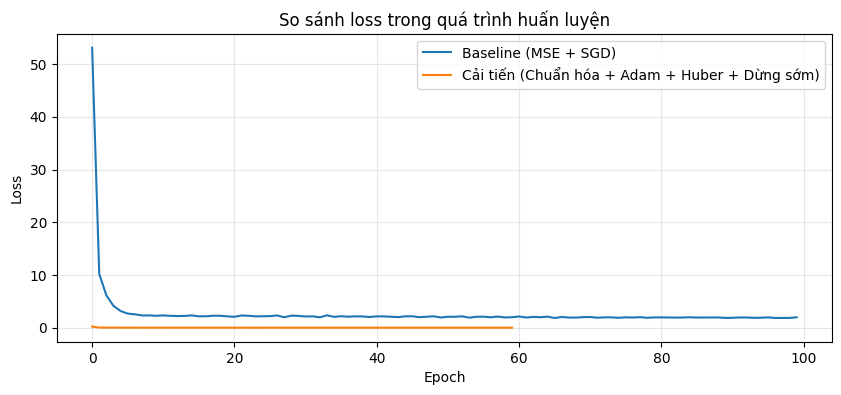

In [12]:
# =========================
# Phần 6: Huấn luyện mô hình baseline và mô hình cải tiến
# =========================

# Mô hình baseline bám sát yêu cầu gốc của bài lab
baseline_model = tf.keras.Sequential([
    tf.keras.Input(shape=[window_size]),
    tf.keras.layers.Dense(1)
 ])

baseline_model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9)
 )

history_baseline = baseline_model.fit(
    dataset,
    epochs=100,
    steps_per_epoch=steps_per_epoch,
    verbose=0
 )

# Mô hình cải tiến nhằm giảm loss và cải thiện sai số dự báo
improved_model = tf.keras.Sequential([
    tf.keras.Input(shape=[window_size]),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
 ])

improved_model.compile(
    loss=tf.keras.losses.Huber(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
 )

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
 )

history_improved = improved_model.fit(
    dataset_norm,
    epochs=120,
    steps_per_epoch=steps_per_epoch,
    callbacks=[early_stop],
    verbose=0
 )

print('Loss cuối cùng của mô hình baseline:', history_baseline.history['loss'][-1])
print('Loss cuối cùng của mô hình cải tiến:', history_improved.history['loss'][-1])

plt.figure(figsize=(10, 4))
plt.plot(history_baseline.history['loss'], label='Baseline (MSE + SGD)')
plt.plot(history_improved.history['loss'], label='Cải tiến (Chuẩn hóa + Adam + Huber + Dừng sớm)')
plt.title('So sánh loss trong quá trình huấn luyện')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Dự đoán, đánh giá và phân tích sai số

Sau khi hoàn tất huấn luyện, hai mô hình được sử dụng để dự đoán trên tập validation. Nội dung của phần này tập trung vào ba mục tiêu chính:

- So sánh trực quan giữa giá trị thực tế và giá trị dự đoán.
- Đo lường sai số bằng `MSE` và `MAE`.
- Phân tích residual để đánh giá phần sai lệch còn mang tính hệ thống hay không.

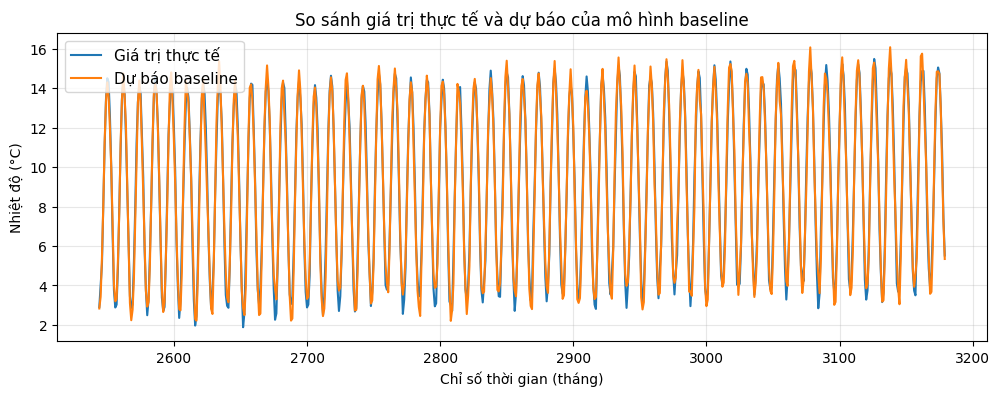

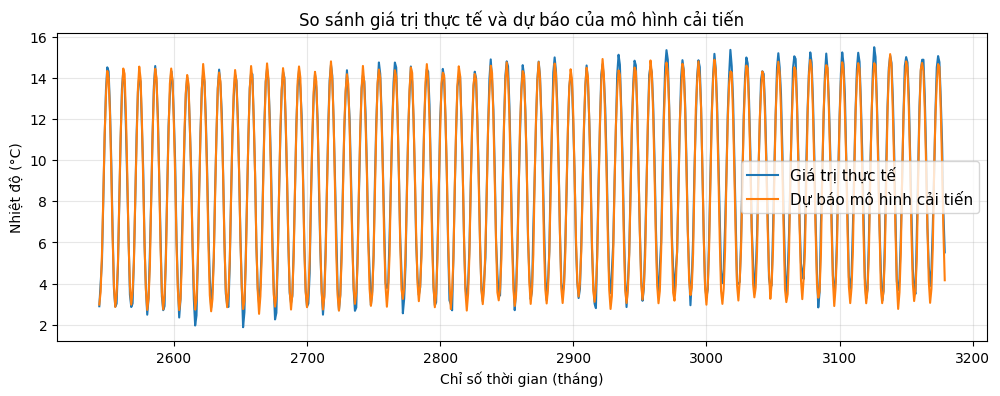

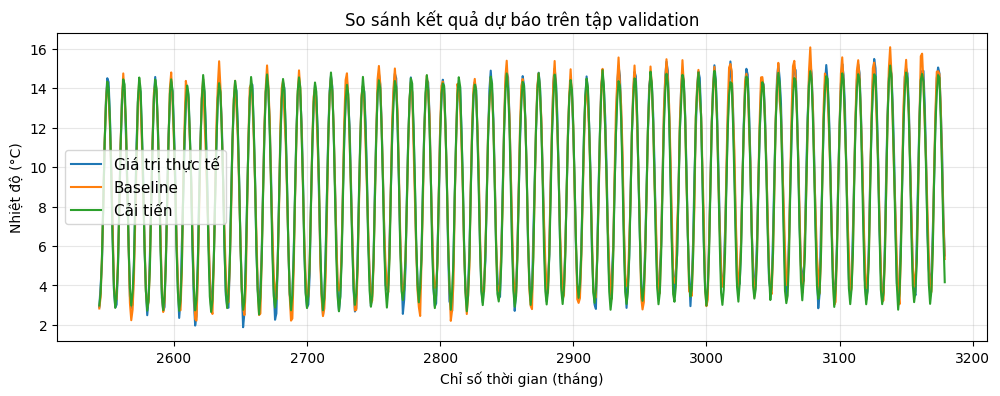

Baseline -> MSE: 0.3295, MAE: 0.4647
Cải tiến -> MSE: 0.2109, MAE: 0.3609


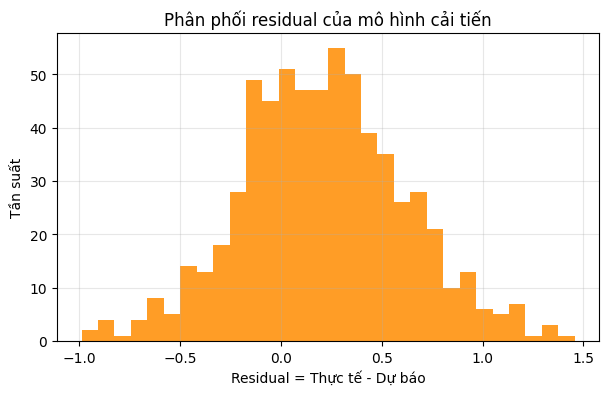

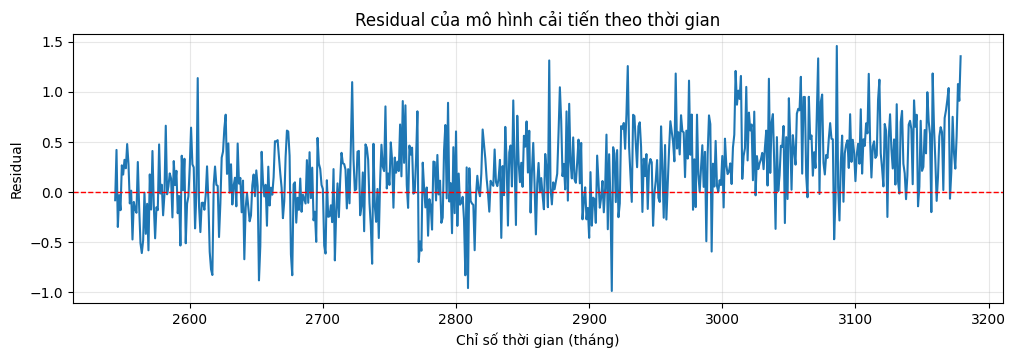

In [13]:
# =========================
# Phần 7: Dự đoán, tính metric và phân tích residual
# =========================

def rolling_forecast(model, input_series, window_size):
    preds = []
    for t in range(len(input_series) - window_size):
        pred = model.predict(input_series[t:t + window_size][np.newaxis], verbose=0)
        preds.append(pred[0, 0])
    return np.array(preds)

# Dự báo bằng mô hình baseline trên dữ liệu gốc
forecast_baseline = rolling_forecast(baseline_model, series, window_size)
forecast_baseline_valid = forecast_baseline[split_time - window_size:]

# Dự báo bằng mô hình cải tiến trên dữ liệu đã chuẩn hóa
series_norm = (series - train_mean) / train_std
forecast_improved_norm = rolling_forecast(improved_model, series_norm, window_size)
forecast_improved_valid = forecast_improved_norm[split_time - window_size:] * train_std + train_mean

# So sánh trực quan giữa dữ liệu thực và dự báo của baseline
plt.figure(figsize=(12, 4))
plot_series(time_valid, x_valid, label='Giá trị thực tế')
plot_series(time_valid, forecast_baseline_valid, label='Dự báo baseline')
plt.title('So sánh giá trị thực tế và dự báo của mô hình baseline')
plt.show()

# So sánh trực quan giữa dữ liệu thực và dự báo của mô hình cải tiến
plt.figure(figsize=(12, 4))
plot_series(time_valid, x_valid, label='Giá trị thực tế')
plot_series(time_valid, forecast_improved_valid, label='Dự báo mô hình cải tiến')
plt.title('So sánh giá trị thực tế và dự báo của mô hình cải tiến')
plt.show()

# So sánh đồng thời cả hai mô hình trên tập validation
plt.figure(figsize=(12, 4))
plot_series(time_valid, x_valid, label='Giá trị thực tế')
plot_series(time_valid, forecast_baseline_valid, label='Baseline')
plot_series(time_valid, forecast_improved_valid, label='Cải tiến')
plt.title('So sánh kết quả dự báo trên tập validation')
plt.show()

# Tính các chỉ số sai số
mse_metric = tf.keras.metrics.MeanSquaredError()
mae_metric = tf.keras.metrics.MeanAbsoluteError()

mse_metric.update_state(x_valid, forecast_baseline_valid)
mae_metric.update_state(x_valid, forecast_baseline_valid)
mse_baseline = mse_metric.result().numpy()
mae_baseline = mae_metric.result().numpy()

mse_metric.reset_state()
mae_metric.reset_state()
mse_metric.update_state(x_valid, forecast_improved_valid)
mae_metric.update_state(x_valid, forecast_improved_valid)
mse_improved = mse_metric.result().numpy()
mae_improved = mae_metric.result().numpy()

print(f'Baseline -> MSE: {mse_baseline:.4f}, MAE: {mae_baseline:.4f}')
print(f'Cải tiến -> MSE: {mse_improved:.4f}, MAE: {mae_improved:.4f}')

# Phân tích residual của mô hình cải tiến
residuals = x_valid - forecast_improved_valid
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=30, color='darkorange', alpha=0.85)
plt.title('Phân phối residual của mô hình cải tiến')
plt.xlabel('Residual = Thực tế - Dự báo')
plt.ylabel('Tần suất')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(12, 3.5))
plt.plot(time_valid, residuals)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residual của mô hình cải tiến theo thời gian')
plt.xlabel('Chỉ số thời gian (tháng)')
plt.ylabel('Residual')
plt.grid(alpha=0.3)
plt.show()

## 8. Kết luận và kiến nghị

### 8.1. Kết luận chung
Qua quá trình xây dựng mô hình, huấn luyện và đánh giá trên bộ dữ liệu khí hậu thực tế, có thể khẳng định rằng cách tiếp cận theo cửa sổ thời gian là phù hợp với bài toán dự báo nhiệt độ trung bình đất liền. Kết quả thực nghiệm cho thấy mô hình baseline đã học được quy luật chính của chuỗi dữ liệu, đặc biệt là thành phần mùa vụ lặp lại theo chu kỳ.

Mặt khác, mô hình cải tiến đạt hiệu quả cao hơn một cách nhất quán trên cả chỉ số sai số và mức độ ổn định trong huấn luyện. Việc kết hợp chuẩn hóa dữ liệu, bộ tối ưu Adam, hàm mất mát Huber và cơ chế EarlyStopping đã giúp cải thiện rõ rệt chất lượng dự báo so với cấu hình baseline.

### 8.2. Đánh giá về ý nghĩa học thuật và thực tiễn
Bài làm đáp ứng đầy đủ mục tiêu của bài lab, đồng thời mở rộng giá trị phân tích khi sử dụng dữ liệu thực thay cho dữ liệu giả lập. Kết quả thu được không chỉ minh họa đúng quy trình xây dựng mô hình chuỗi thời gian trong học phần, mà còn cho thấy khả năng ứng dụng vào các bối cảnh dữ liệu khí hậu có tính mùa vụ và xu hướng dài hạn.

### 8.3. Hạn chế của mô hình hiện tại
Mặc dù kết quả dự báo đã được cải thiện, mô hình hiện tại vẫn thuộc nhóm kiến trúc đơn giản. Do đó, mô hình có thể chưa khai thác tối đa các quan hệ phụ thuộc dài hạn và những dao động phức tạp theo thời gian.

### 8.4. Kiến nghị hướng phát triển
Trong các nghiên cứu tiếp theo, nên xem xét mở rộng theo các hướng:
- Thử nghiệm các kiến trúc chuyên biệt cho chuỗi thời gian như Conv1D, RNN, LSTM.
- Tối ưu thêm siêu tham số (window size, learning rate, batch size, số tầng ẩn).
- Bổ sung các chỉ số đánh giá khác và kiểm định độ ổn định mô hình theo nhiều giai đoạn thời gian.

Nhìn chung, bài thực hành đã đạt mục tiêu đề ra và cung cấp một nền tảng phù hợp để tiếp tục phát triển các mô hình dự báo chuỗi thời gian ở mức độ nâng cao hơn.

## 9. Insight rút ra từ dữ liệu

Phần này tổng hợp các phát hiện định lượng quan trọng rút ra trực tiếp từ chuỗi nhiệt độ trung bình đất liền toàn cầu. Những insight này hỗ trợ cho phần nhận xét cuối bài và giúp làm rõ đặc trưng của bộ dữ liệu được sử dụng.

Xu hướng tăng nhiệt độ ước lượng: 0.0047 °C/năm (~0.047 °C/thập kỷ)
Nhiệt độ trung bình của 50 năm đầu: 8.178 °C
Nhiệt độ trung bình của 50 năm cuối: 9.087 °C
Nhiệt độ trung bình của 100 năm đầu: 8.034 °C
Nhiệt độ trung bình của 100 năm cuối: 8.838 °C
Nhiệt độ trung bình của 30 năm trước giai đoạn gần nhất: 8.687 °C
Nhiệt độ trung bình của 30 năm gần nhất: 9.339 °C
Mức chênh lệch giữa hai giai đoạn 30 năm cuối: 0.653 °C
Tháng có nhiệt độ trung bình cao nhất: tháng 7
Tháng có nhiệt độ trung bình thấp nhất: tháng 1
Biên độ mùa vụ: 12.033 °C
Độ lệch chuẩn giai đoạn 1750-1849: 4.555
Độ lệch chuẩn giai đoạn 1900-1999: 4.197
Độ lệch chuẩn giai đoạn 1986-2015: 4.133

5 năm nóng nhất:
dt
2015    9.831
2007    9.732
2010    9.703
2005    9.701
2013    9.606
Name: LandAverageTemperature, dtype: float64

5 năm lạnh nhất:
dt
1752    5.780
1758    6.744
1768    6.781
1811    6.860
1810    6.923
Name: LandAverageTemperature, dtype: float64


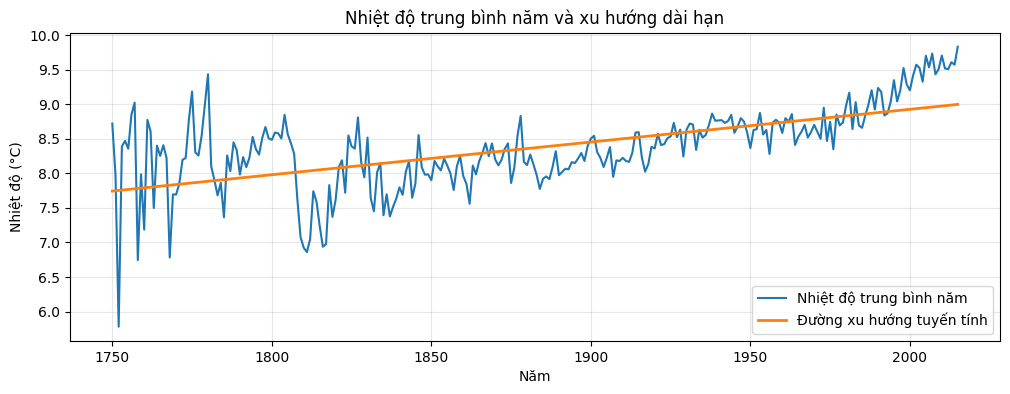

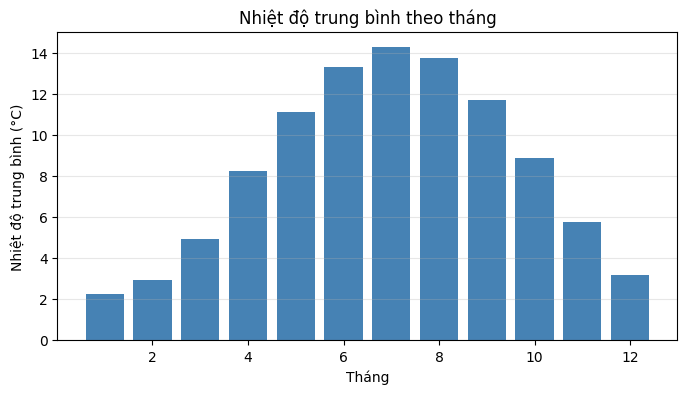

In [14]:
# =========================
# Phần 9: Rút ra insight định lượng từ bộ dữ liệu
# =========================

yearly_avg = df_temp.groupby(df_temp['dt'].dt.year)['LandAverageTemperature'].mean()
monthly_avg = df_temp.groupby(df_temp['dt'].dt.month)['LandAverageTemperature'].mean()

# Ước lượng xu hướng tăng nhiệt độ dài hạn theo trung bình năm
trend_coef = np.polyfit(yearly_avg.index.to_numpy(), yearly_avg.to_numpy(), 1)
warming_per_year = trend_coef[0]
warming_per_decade = warming_per_year * 10

# So sánh các giai đoạn đầu và cuối của chuỗi dữ liệu
first_50_mean = yearly_avg.iloc[:50].mean()
last_50_mean = yearly_avg.iloc[-50:].mean()
first_100_mean = yearly_avg.iloc[:100].mean()
last_100_mean = yearly_avg.iloc[-100:].mean()
previous_30_mean = yearly_avg.iloc[-60:-30].mean()
recent_30_mean = yearly_avg.iloc[-30:].mean()

# Phân tích mùa vụ theo từng tháng
warmest_month = monthly_avg.idxmax()
coolest_month = monthly_avg.idxmin()
seasonal_amplitude = monthly_avg.max() - monthly_avg.min()

# So sánh mức độ biến động giữa các giai đoạn
std_1750_1849 = df_temp[(df_temp['dt'].dt.year >= 1750) & (df_temp['dt'].dt.year <= 1849)]['LandAverageTemperature'].std()
std_1900_1999 = df_temp[(df_temp['dt'].dt.year >= 1900) & (df_temp['dt'].dt.year <= 1999)]['LandAverageTemperature'].std()
std_1986_2015 = df_temp[(df_temp['dt'].dt.year >= 1986) & (df_temp['dt'].dt.year <= 2015)]['LandAverageTemperature'].std()

# Xác định các năm nóng nhất và lạnh nhất
warmest_years = yearly_avg.sort_values(ascending=False).head(5)
coolest_years = yearly_avg.sort_values().head(5)

print(f'Xu hướng tăng nhiệt độ ước lượng: {warming_per_year:.4f} °C/năm (~{warming_per_decade:.3f} °C/thập kỷ)')
print(f'Nhiệt độ trung bình của 50 năm đầu: {first_50_mean:.3f} °C')
print(f'Nhiệt độ trung bình của 50 năm cuối: {last_50_mean:.3f} °C')
print(f'Nhiệt độ trung bình của 100 năm đầu: {first_100_mean:.3f} °C')
print(f'Nhiệt độ trung bình của 100 năm cuối: {last_100_mean:.3f} °C')
print(f'Nhiệt độ trung bình của 30 năm trước giai đoạn gần nhất: {previous_30_mean:.3f} °C')
print(f'Nhiệt độ trung bình của 30 năm gần nhất: {recent_30_mean:.3f} °C')
print(f'Mức chênh lệch giữa hai giai đoạn 30 năm cuối: {recent_30_mean - previous_30_mean:.3f} °C')
print(f'Tháng có nhiệt độ trung bình cao nhất: tháng {int(warmest_month)}')
print(f'Tháng có nhiệt độ trung bình thấp nhất: tháng {int(coolest_month)}')
print(f'Biên độ mùa vụ: {seasonal_amplitude:.3f} °C')
print(f'Độ lệch chuẩn giai đoạn 1750-1849: {std_1750_1849:.3f}')
print(f'Độ lệch chuẩn giai đoạn 1900-1999: {std_1900_1999:.3f}')
print(f'Độ lệch chuẩn giai đoạn 1986-2015: {std_1986_2015:.3f}')

print('\n5 năm nóng nhất:')
print(warmest_years.round(3))

print('\n5 năm lạnh nhất:')
print(coolest_years.round(3))

plt.figure(figsize=(12, 4))
plt.plot(yearly_avg.index, yearly_avg.values, label='Nhiệt độ trung bình năm')
plt.plot(yearly_avg.index, np.polyval(trend_coef, yearly_avg.index), label='Đường xu hướng tuyến tính', linewidth=2)
plt.title('Nhiệt độ trung bình năm và xu hướng dài hạn')
plt.xlabel('Năm')
plt.ylabel('Nhiệt độ (°C)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(monthly_avg.index, monthly_avg.values, color='steelblue')
plt.title('Nhiệt độ trung bình theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Nhiệt độ trung bình (°C)')
plt.grid(axis='y', alpha=0.3)
plt.show()